# Determination of realistic parameters
## Heat Exhanger parameters 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Tapwater: UAs = 1537.9327501929886 W/K, U = 4000 W/m2K => As = 0.3844831875482471 m2
Spaceheating: transferred heat with tapwater parameters 7305.180563416696


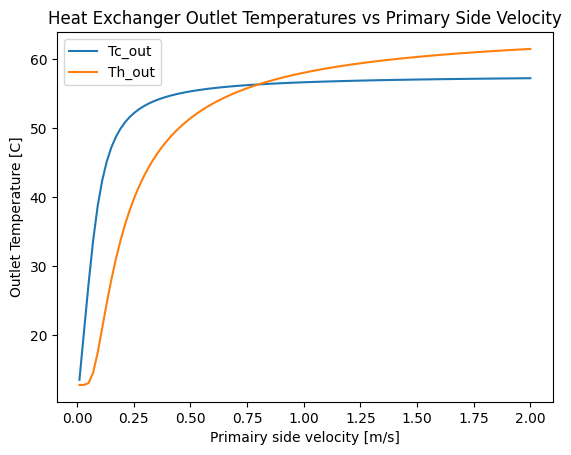

In [ ]:
# Determination of Heat Exhanger parameters 
c_water = 4.18e3 
U = 4000  # Overall heat transfer coefficient [W/m2K] obtained via site https://www.engineeringtoolbox.com/heat-transfer-coefficients-exchangers-d_450.html

# Qdot = U * As * F * delta_T_mean
# For tapwater heater
Th_in = 65
Th_out = 35
Tc_in = 10
Tc_out = 60
Qdot = 30e3 # W
F = 0.95

dTmean = (Th_in - Tc_out) - (Th_out - Tc_in) / \
            np.log((Th_in - Tc_out)/(Th_out - Tc_in))

UAs = Qdot / (dTmean * F)
print(f'Tapwater: UAs = {UAs} W/K, U = 4000 W/m2K => As = {UAs/4000} m2')

# For spaceheating
Th_in = 65
Th_out = 35
Tc_in = 30
Tc_out = 60
F = 0.95

delta1 = Th_in - Tc_out
delta2 = Th_out - Tc_in

if delta1 == delta2: 
    dTmean = delta1
else:
    dTmean = (Th_in - Tc_out) - (Th_out - Tc_in) / \
                np.log((Th_in - Tc_out)/(Th_out - Tc_in))

Qdot = UAs * (dTmean * F)
print(f'Spaceheating: transferred heat with tapwater parameters {Qdot}')

# Higher UAs needed for tapwater requires less flow for the space heating system. 
# But now the problem is that the 


def NTU_method(vh_in):
 
    mflow_c = 0.15 # kg/s, max cold side flow rate 
    mflow_h = vh_in # 1 m/s velocity, density 1000 kg/m3

    Th_in = 65
    Tc_in = 10
    F = 0.95

    # Heat capacity rates
    Cc = mflow_c * c_water
    Ch = mflow_h * c_water         

    Cmin = min(Cc, Ch)
    Cmax = max(Cc, Ch)
    Cr = Cmin / Cmax

    NTU = (UAs) / Cmin

    # Effectiveness calculation for counterflow heat exchanger
    if Cr != 1:
        epsilon = (1 - np.exp(-NTU * (1 - Cr))) / (1 - Cr * np.exp(-NTU * (1 - Cr)))
    else:
        epsilon = NTU / (1 + NTU)

    Q = F * epsilon * Cmin * (Th_in - Tc_in)

    Tc_out = Tc_in + Q / Cc
    Th_out = Th_in - Q / Ch
    
    return Tc_out, Th_out

vh_in = np.linspace(0.01,2,100)
Tc_out_array = []
Th_out_array = []   
for v in vh_in:
    Tc_out, Th_out = NTU_method(v)
    Tc_out_array.append(Tc_out)
    Th_out_array.append(Th_out)

plt.plot(vh_in, Tc_out_array, label='Tc_out')
plt.plot(vh_in, Th_out_array, label='Th_out')
plt.xlabel('Primairy side velocity [m/s]')
plt.ylabel('Outlet Temperature [C]')
plt.title('Heat Exchanger Outlet Temperatures vs Primary Side Velocity')
plt.legend()
plt.show()

# Pressure relation HEX

dp_hex = rho * K_p * Q ** 2, with dp_hex = 35 kPa according to brochure \
30 kW = c_p * Qprim * dT_prim_tap -> Qprim = 30 / (4.18 * 30) = 0.24 kg/s \
K_p = 35e3 / (0.24 ^2 * 1000) = 607 kg2/m2

In [ ]:
# Determination of the Reynolds number based on the Darcy-Weisbach equation
L  = 3  # m
D = 0.04 # m
v = 0.87 # m/s
dp = 803.5  # Pa

rho = 1000 # kg/m3
epsilon = 0.045e-3 # m

# Re = rho * v * D / mu
mu = 0.001 # Pa.s
Re_check = rho * v * D / mu
f_check = (1 / (-1.8 * np.log10( (epsilon/D)/3.7**1.11 + 6.9/Re_check)))**2
dp = f_check * L * rho * v**2 / (2 * D)
# print(f'f_check = {f_check}, Re check = {Re_check}, dp check = {dp} Pa')

# Solve Haaland equation for Re
f = 2 * dp * D / (L * rho * v**2)
e_term = (epsilon/D/3.7)**1.11
Re = 6.9 / (10**(-1/(1.8*np.sqrt(f))) - e_term)

# print(f' f = {f}, dp = {dp} Pa, Re = {Re}, epsilon/D = {epsilon/D}')

# Equal percentage valve

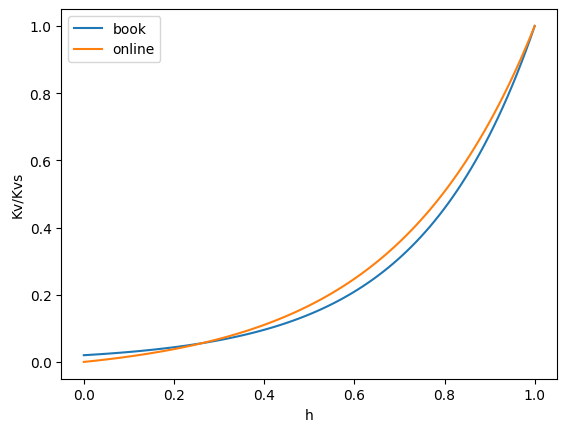

In [ ]:
# functions return Kv/Kvs

def Kv_book(h, Kv0):
    Kvs = 0.1
    return (Kvs / Kv0) ** (h-1)

def Kv_online(h,n):
    return (np.exp(n*h) - 1) / (np.exp(n)-1)


h = np.linspace(0,1,100)

Kv_book_array = []
Kv_online_array = []
for hi in h:
    Kv_book_array.append(Kv_book(hi,0.1/50))
    Kv_online_array.append(Kv_online(hi,3.2))

# In phd thesis he says that the typical ratio between Kvs/Kv0 is between 25 - 50. Higher ratio means beter control flow. 
# And got from Robbert that the Kvs value is approx 0.1 

plt.figure()
plt.plot(h,Kv_book_array, label = 'book')
plt.plot(h,Kv_online_array, label = 'online')
plt.legend()
plt.xlabel('h (-)')
plt.ylabel('Kv/Kvs (-)')
plt.show()

# Pump

[ -4221.7159851  -18568.07669405  50000.        ]


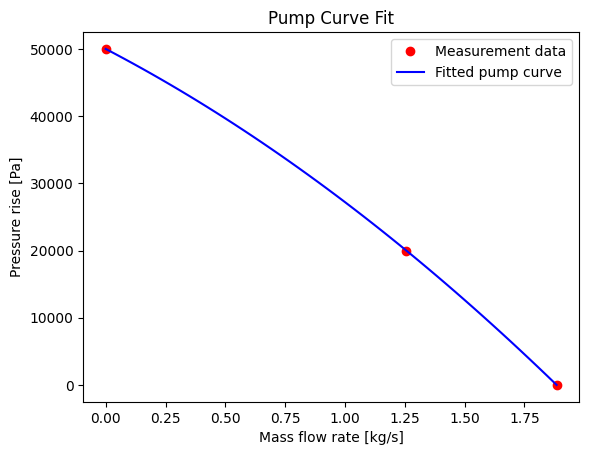

In [ ]:
# Measurement data points
mflow_max = 0.6 * np.pi  # kg/s
dp_data = np.array([50e3, 20e3, 0])  # Pa
mflow_data = np.array([0, 0.4*np.pi, mflow_max])  # kg/s

# Fit quadratic curve to data: dp = a*mflow^2 + b*mflow + c
coefficients = np.polyfit(mflow_data, dp_data, 2)
a, b, c = coefficients

print(coefficients)

# Update pump_curve function with fitted coefficients
def pump_curve(mflow):
    dp = a * mflow**2 + b * mflow + c
    return dp

# Verify fit
mflow_test = np.linspace(0, mflow_max, 50)
dp_fit = [pump_curve(m) for m in mflow_test]

plt.figure()
plt.plot(mflow_data, dp_data, 'ro', label='Measurement data')
plt.plot(mflow_test, dp_fit, 'b-', label='Fitted pump curve')
plt.xlabel('Mass flow rate [kg/s]')
plt.ylabel('Pressure rise [Pa]')
plt.title('Pump Curve Fit')
plt.legend()
plt.show()